In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
# Load data
historical_df = pd.read_csv('historical.csv')
y_actual = historical_df['outcome']
is_fraud = y_actual == 1

# Threshold function
def thresholds_fraud(amounts, threshold):
    return (amounts >= threshold).astype(int)

# Define thresholds to test
min_fraud_amount = historical_df.loc[is_fraud, 'Amount'].min()
max_fraud_amount = historical_df.loc[is_fraud, 'Amount'].max()
thresholds = np.linspace(min_fraud_amount, max_fraud_amount, 100)

# Store metrics
fraud_capture_rates = []
detection_rates = []
net_savings = []

for t in thresholds:
    y_pred = thresholds_fraud(historical_df['Amount'], t)
    
    # Fraud Capture Rate
    true_positives = ((y_pred == 1) & (y_actual == 1)).sum()
    actual_positives = (y_actual == 1).sum()
    fraud_capture_rate = true_positives / actual_positives if actual_positives > 0 else 0
    fraud_capture_rates.append(fraud_capture_rate)
    
    # Precision
    predicted_positives = (y_pred == 1).sum()
    precision = true_positives / predicted_positives if predicted_positives > 0 else 0
    detection_rates.append(precision)
    
    # Net Savings Score
    true_positives_mask = (y_pred == 1) & (y_actual == 1)
    false_positives_mask = (y_pred == 1) & (y_actual == 0)
    tp_sum = historical_df.loc[true_positives_mask, 'Amount'].sum()
    fp_sum = historical_df.loc[false_positives_mask, 'Amount'].sum()
    net_savings.append(tp_sum - fp_sum)


In [44]:
threshold_df = pd.DataFrame({'threshold' : thresholds,
              'fraud_capture_rate': fraud_capture_rates,
              'precision': precision,
              'net_savings': net_savings})
threshold_df.to_csv('thresholds.csv')

In [61]:
len(np.array(fraud_capture_rates) * 100)

100

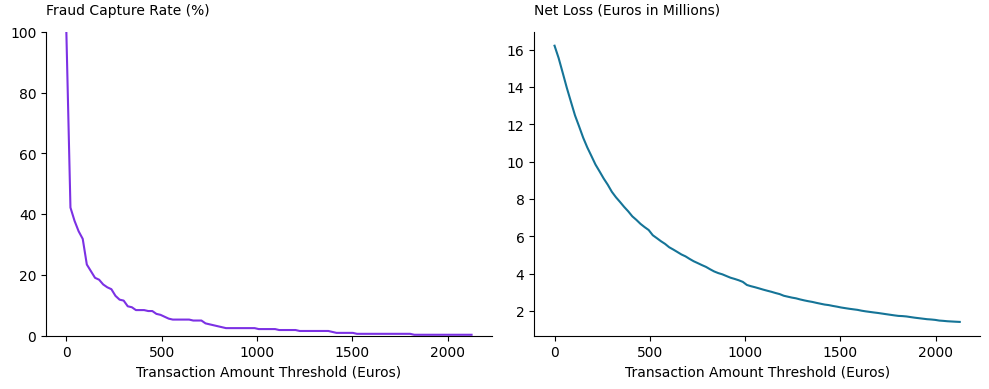

In [64]:
# Scale net savings to millions
net_savings_millions = np.array(net_savings) / 1e6
fraud_capture_rates_percent = np.array(fraud_capture_rates) * 100

# Create combined figure with 3 subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# Fraud Capture Rate
axes[0].plot(thresholds, fraud_capture_rates_percent, color='#7c31e4')
axes[0].set_ylabel('Fraud Capture Rate (%)', rotation=0, ha='left')
axes[0].set_ylim(0, 100)

# Net Savings Score in Millions
axes[1].plot(thresholds, -net_savings_millions, color='#157497')
axes[1].set_ylabel('Net Loss (Euros in Millions)', rotation=0, ha='left')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Transaction Amount Threshold (Euros)')
    ax.yaxis.set_label_coords(0, 1.05)

plt.tight_layout()
plt.show()
